# 🔍 Template EDA Profissional
**Autor:** Miguel Salles Reis · [github.com/miguelsalles-dtscience](https://github.com/miguelsalles-dtscience)

> Template de Análise Exploratória de Dados com rigor estatístico, limpeza automática, testes de hipótese e relatório HTML exportável.
> Substitua o dataset de exemplo pelo seu CSV e execute célula a célula.

---

## O que este template faz

| Seção | O que entrega |
|-------|--------------|
| 0 · Configuração | Imports, paleta de cores, funções auxiliares |
| 1 · Carregamento | Leitura do CSV com diagnóstico inicial |
| 2 · Data Quality Score | Nota de 0–100 para a qualidade do dataset |
| 3 · Limpeza automática | Nulos, duplicatas, tipos, outliers |
| 4 · EDA Univariada | Distribuições, skewness, curtose |
| 5 · EDA Bivariada | Correlações com teste de significância |
| 6 · Testes de Hipótese | Normalidade, comparação de grupos |
| 7 · Detecção de Outliers | IQR + Z-score + Isolation Forest |
| 8 · Relatório HTML | Exportação automática com narrativa |


## ⚙️ Seção 0 — Configuração

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# SEÇÃO 0 — IMPORTS E CONFIGURAÇÃO GLOBAL
# ══════════════════════════════════════════════════════════════════════════════

# Manipulação e análise de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Estatística inferencial
# scipy.stats contém todos os testes clássicos: t-test, ANOVA,
# Shapiro-Wilk, Pearson, Spearman, Mann-Whitney, etc.
from scipy import stats

# Machine learning — usado na detecção de outliers com Isolation Forest
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Utilitários
import warnings
import os
from datetime import datetime
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Paleta de cores consistente em todo o projeto ─────────────────────────────
# Definir uma paleta fixa garante que todos os gráficos tenham identidade visual
# coerente — detalhe que diferencia um trabalho amador de um profissional.
PALETTE = {
    "primary":   "#1B5E8A",   # Azul escuro — cor principal
    "secondary": "#5B9DC9",   # Azul médio — cor secundária
    "accent":    "#E07B39",   # Laranja — destaque e alertas
    "success":   "#2E8B57",   # Verde — indicadores positivos
    "danger":    "#C0392B",   # Vermelho — problemas e outliers
    "neutral":   "#7F8C8D",   # Cinza — elementos de apoio
    "bg":        "#F8F9FA",   # Fundo claro
}

# Lista de cores para gráficos com múltiplas categorias
COLORS = [PALETTE["primary"], PALETTE["secondary"], PALETTE["accent"],
          PALETTE["success"], PALETTE["danger"], PALETTE["neutral"],
          "#8E44AD", "#F39C12", "#16A085"]

# ── Configurações globais do Matplotlib ──────────────────────────────────────
# plt.rcParams é um dicionário que guarda todas as configurações padrão
# do matplotlib. Alterá-lo aqui aplica a configuração a TODOS os gráficos
# do notebook, sem precisar repetir em cada um.
plt.rcParams.update({
    "figure.facecolor":  PALETTE["bg"],
    "axes.facecolor":    PALETTE["bg"],
    "axes.spines.top":   False,    # Remove borda superior de todos os gráficos
    "axes.spines.right": False,    # Remove borda direita
    "axes.grid":         True,
    "grid.alpha":        0.35,
    "grid.color":        "#CCCCCC",
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "figure.dpi":        120,      # Alta resolução para exportação
})

# ── Funções auxiliares de formatação ─────────────────────────────────────────

def fmt_numero(v, decimais=2):
    """Formata um número com separador de milhar e decimais."""
    return f"{v:,.{decimais}f}"

def fmt_pct(v, decimais=1):
    """Formata um número como porcentagem."""
    return f"{v:.{decimais}f}%"

def separador(titulo="", char="═", largura=70):
    """Imprime um separador visual no output — melhora legibilidade dos prints."""
    if titulo:
        lado = (largura - len(titulo) - 2) // 2
        print(f"{char*lado} {titulo} {char*lado}")
    else:
        print(char * largura)

# ── Pasta de saída para gráficos e relatório ─────────────────────────────────
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)  # Cria a pasta se não existir

print("✅ Configuração carregada com sucesso.")
print(f"   Output directory: {OUTPUT_DIR.resolve()}")

✅ Configuração carregada com sucesso.
   Output directory: C:\Users\migue\OneDrive\Desktop\portfolio-template-eda\outputs


## 📂 Seção 1 — Carregamento e Diagnóstico Inicial

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# SEÇÃO 1 — CARREGAMENTO DO DATASET
# ══════════════════════════════════════════════════════════════════════════════
# INSTRUÇÃO: Substitua o caminho abaixo pelo seu arquivo CSV.
# O template gera dados fictícios se o arquivo não for encontrado,
# para que você possa testar sem ter um CSV em mãos.

CSV_PATH = "seu_dataset.csv"   # ← ALTERE AQUI

# ── Geração de dataset de demonstração ───────────────────────────────────────
# Este bloco simula um dataset real de RH com problemas intencionais
# (nulos, outliers, tipos errados) para demonstrar a limpeza automática.
def gerar_dataset_demo(n=500, seed=42):
    """
    Gera um dataset fictício de RH com problemas realistas.
    Usado apenas quando nenhum CSV é fornecido.

    Problemas embutidos propositalmente:
    - Valores nulos em múltiplas colunas
    - Outliers extremos em salário e idade
    - Duplicatas
    - Coluna de data como string (tipo errado)
    - Inconsistências de categoria (maiúsculas/minúsculas)
    """
    np.random.seed(seed)

    departamentos = ["Vendas", "TI", "RH", "Financeiro", "Operações"]
    generos = ["Masculino", "Feminino", "Não informado"]

    # Geramos os dados base
    df = pd.DataFrame({
        "id":             range(1, n + 1),
        "nome":           [f"Funcionário_{i:04d}" for i in range(1, n + 1)],
        "departamento":   np.random.choice(departamentos, n, p=[0.30,0.25,0.15,0.20,0.10]),
        "genero":         np.random.choice(generos, n, p=[0.52, 0.45, 0.03]),
        "idade":          np.random.normal(35, 8, n).clip(22, 60).round().astype(int),
        "anos_empresa":   np.random.exponential(4, n).clip(0, 20).round(1),
        "salario":        np.random.lognormal(8.5, 0.5, n).round(2),
        "satisfacao":     np.random.choice([1,2,3,4,5], n, p=[0.05,0.10,0.25,0.40,0.20]),
        "ausencias_ano":  np.random.poisson(3, n),
        "data_admissao":  pd.date_range("2010-01-01", periods=n, freq="3D").strftime("%d/%m/%Y"),
        "performance":    np.random.normal(70, 15, n).clip(0, 100).round(1),
        "cargo_nivel":    np.random.choice(["Junior","Pleno","Senior","Lider"], n, p=[0.35,0.35,0.20,0.10]),
    })

    # ── Injetamos problemas propositalmente para demonstrar a limpeza ─────────

    # 1. Nulos aleatórios (~8% de cada coluna)
    for col in ["satisfacao", "performance", "anos_empresa", "genero"]:
        mask = np.random.random(n) < 0.08
        df.loc[mask, col] = np.nan

    # 2. Outliers extremos em salário (simula erro de digitação)
    idx_outlier = np.random.choice(n, 5, replace=False)
    multiplicadores = np.random.choice([10, 0.1], 5)
    df.loc[idx_outlier, "salario"] = df.loc[idx_outlier, "salario"].values * multiplicadores

    # 3. Duplicatas (5 registros duplicados)
    duplicatas = df.sample(5, random_state=42)
    df = pd.concat([df, duplicatas]).reset_index(drop=True)

    # 4. Inconsistências de categoria
    mask_ti = df["departamento"] == "TI"
    df.loc[mask_ti & (np.random.random(len(df)) < 0.3), "departamento"] = "ti"

    return df

# ── Carregamento com fallback para demo ───────────────────────────────────────
try:
    # Tentamos ler o arquivo do usuário
    # O pandas detecta automaticamente separadores comuns (vírgula, ponto-e-vírgula, tab)
    df_raw = pd.read_csv(CSV_PATH, sep=None, engine="python", encoding="utf-8")
    print(f"✅ Dataset carregado: {CSV_PATH}")
    MODO_DEMO = False
except FileNotFoundError:
    print("⚠️  Arquivo não encontrado — usando dataset de demonstração (RH fictício).")
    print("   Para usar seus dados: altere CSV_PATH no início desta célula.\n")
    df_raw = gerar_dataset_demo()
    MODO_DEMO = True

# Criamos uma cópia de trabalho — preservamos o raw para comparação posterior
df = df_raw.copy()

# ── Diagnóstico inicial ───────────────────────────────────────────────────────
separador("DIAGNÓSTICO INICIAL")
print(f"  Linhas:    {df.shape[0]:,}")
print(f"  Colunas:   {df.shape[1]}")
print(f"  Memória:   {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print(f"  Período:   {datetime.now().strftime('%d/%m/%Y %H:%M')}")
print()

separador("TIPOS DE DADOS")
# dtypes retorna o tipo de cada coluna (int64, float64, object, datetime64, etc.)
# value_counts() conta quantas colunas há de cada tipo
for dtype, count in df.dtypes.value_counts().items():
    print(f"  {str(dtype):<15} {count} coluna(s)")
print()

separador("PRIMEIRAS LINHAS")
df.head()

⚠️  Arquivo não encontrado — usando dataset de demonstração (RH fictício).
   Para usar seus dados: altere CSV_PATH no início desta célula.

════════════════════════ DIAGNÓSTICO INICIAL ════════════════════════
  Linhas:    505
  Colunas:   12
  Memória:   68.4 KB
  Período:   23/05/2026 03:05

═══════════════════════════ TIPOS DE DADOS ═══════════════════════════
  str             5 coluna(s)
  float64         4 coluna(s)
  int64           2 coluna(s)
  int32           1 coluna(s)

══════════════════════════ PRIMEIRAS LINHAS ══════════════════════════


,id,nome,departamento,genero,idade,anos_empresa,salario,satisfacao,ausencias_ano,data_admissao,performance,cargo_nivel
0,1,Funcionário_0001,TI,NaN,36,0.5,1701.17,5.0,3,01/01/2010,65.8,Pleno
1,2,Funcionário_0002,Operações,NaN,24,7.0,3626.74,4.0,2,04/01/2010,71.5,Junior
2,3,Funcionário_0003,Financeiro,Masculino,38,6.1,9400.30,3.0,2,07/01/2010,72.3,Pleno
3,4,Funcionário_0004,RH,Feminino,40,4.9,4858.89,NaN,3,10/01/2010,69.4,Pleno
4,5,Funcionário_0005,Vendas,Feminino,39,0.1,2982.00,3.0,1,13/01/2010,71.0,Lider


## 🏆 Seção 2 — Data Quality Score

> **Diferencial:** Em vez de só listar problemas, calculamos uma **nota objetiva de qualidade** para o dataset — algo que clientes e recrutadores nunca viram num template comum.

═════════════════════════ DATA QUALITY SCORE ═════════════════════════
  🟢 Completude           [███████████████████░] 97.1/100
  🟢 Unicidade            [███████████████████░] 99.0/100
  🟢 Consistencia         [███████████████████░] 99.0/100
  🟢 Validade_tipos       [████████████████████] 100.0/100
  🟢 Cardinalidade        [███████████████████░] 95.0/100

  SCORE TOTAL          🟢 98.0/100  — Excelente qualidade

══════════════════════════════ DETALHES ══════════════════════════════
  Valores nulos:       178
  Colunas com nulos:   4
  Linhas duplicadas:   5
  Outliers extremos:   1


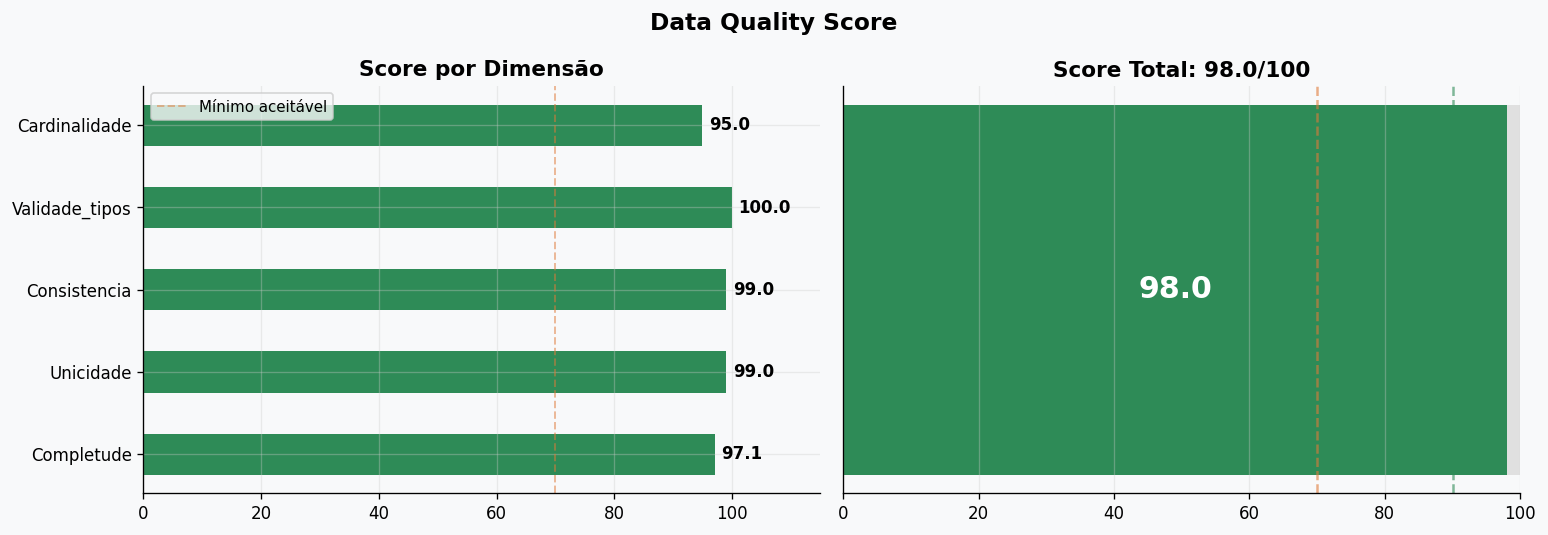

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# SEÇÃO 2 — DATA QUALITY SCORE (DIFERENCIAL)
# ══════════════════════════════════════════════════════════════════════════════
# Um Data Quality Score transforma problemas subjetivos ("tem alguns nulos")
# em uma métrica objetiva e comparável entre datasets.
# Isso é o que separa uma análise de cientista de dados de uma análise
# de analista júnior.

def calcular_dq_score(df):
    """
    Calcula o Data Quality Score do dataset em 5 dimensões.

    Retorna um dicionário com:
      - scores: nota 0-100 por dimensão
      - score_total: média ponderada final
      - detalhes: informações brutas para o relatório
    """
    scores = {}
    detalhes = {}

    # ── DIMENSÃO 1: Completude (peso 30%) ─────────────────────────────────
    # Mede a proporção de valores não-nulos em todo o dataset.
    # Fórmula: 100 * (1 - taxa_de_nulos)
    taxa_nulos = df.isnull().mean().mean()          # Média de nulos por coluna
    scores["completude"] = round(100 * (1 - taxa_nulos), 1)
    detalhes["nulos_total"] = df.isnull().sum().sum()
    detalhes["colunas_com_nulos"] = (df.isnull().sum() > 0).sum()

    # ── DIMENSÃO 2: Unicidade (peso 20%) ──────────────────────────────────
    # Mede a proporção de linhas únicas.
    # Duplicatas inflam análises e distorcem métricas de frequência.
    n_duplicatas = df.duplicated().sum()
    scores["unicidade"] = round(100 * (1 - n_duplicatas / len(df)), 1)
    detalhes["duplicatas"] = int(n_duplicatas)

    # ── DIMENSÃO 3: Consistência (peso 20%) ───────────────────────────────
    # Verifica se colunas numéricas têm valores dentro de faixas plausíveis.
    # Detectamos outliers extremos (além de 5 desvios padrão) como inconsistências.
    cols_num = df.select_dtypes(include=np.number).columns
    if len(cols_num) > 0:
        z_scores = np.abs(stats.zscore(df[cols_num].dropna()))
        n_extremos = (z_scores > 5).sum().sum()
        scores["consistencia"] = round(max(0, 100 - (n_extremos / len(df)) * 500), 1)
    else:
        scores["consistencia"] = 100.0
    detalhes["outliers_extremos"] = int(n_extremos) if len(cols_num) > 0 else 0

    # ── DIMENSÃO 4: Validade de tipos (peso 15%) ──────────────────────────
    # Verifica se colunas com nome de data são realmente datetime.
    # Colunas "object" que deveriam ser numéricas são penalizadas.
    penalidade_tipo = 0
    for col in df.columns:
        if any(kw in col.lower() for kw in ["data", "date", "dt_", "_dt"]):
            if df[col].dtype == "object":
                penalidade_tipo += 10   # -10 pontos por coluna de data como string
    scores["validade_tipos"] = max(0, 100 - penalidade_tipo)

    # ── DIMENSÃO 5: Cardinalidade (peso 15%) ──────────────────────────────
    # Verifica se colunas categóricas (object) têm cardinalidade razoável.
    # Uma coluna com 90%+ de valores únicos provavelmente é um ID, não categoria.
    cols_cat = df.select_dtypes(include="object").columns
    penalidade_card = 0
    for col in cols_cat:
        if col.lower() in ["id", "nome", "name", "cpf", "email"]:
            continue   # Ignoramos colunas de identificação
        unicidade_col = df[col].nunique() / len(df)
        if unicidade_col > 0.9:
            penalidade_card += 5
    scores["cardinalidade"] = max(0, 100 - penalidade_card)

    # ── Score total ponderado ─────────────────────────────────────────────
    pesos = {
        "completude":      0.30,
        "unicidade":       0.20,
        "consistencia":    0.20,
        "validade_tipos":  0.15,
        "cardinalidade":   0.15,
    }
    score_total = sum(scores[k] * pesos[k] for k in scores)

    return {
        "scores":       scores,
        "score_total":  round(score_total, 1),
        "detalhes":     detalhes,
        "pesos":        pesos,
    }


# Calculamos o score do dataset atual
dq = calcular_dq_score(df)

# ── Impressão dos resultados ──────────────────────────────────────────────────
separador("DATA QUALITY SCORE")

# Emoji baseado na nota — feedback visual rápido
def emoji_nota(v):
    if v >= 90: return "🟢"
    if v >= 70: return "🟡"
    return "🔴"

for dim, score in dq["scores"].items():
    barra = "█" * int(score / 5) + "░" * (20 - int(score / 5))
    print(f"  {emoji_nota(score)} {dim.capitalize():<20} [{barra}] {score:.1f}/100")

print()
total = dq["score_total"]
print(f"  {'SCORE TOTAL':<20} {emoji_nota(total)} {total:.1f}/100", end="")
if total >= 90:   print("  — Excelente qualidade")
elif total >= 70: print("  — Boa qualidade, ajustes menores")
elif total >= 50: print("  — Qualidade razoável, limpeza necessária")
else:             print("  — Qualidade baixa, limpeza extensiva necessária")

print()
separador("DETALHES")
print(f"  Valores nulos:       {dq['detalhes']['nulos_total']:,}")
print(f"  Colunas com nulos:   {dq['detalhes']['colunas_com_nulos']}")
print(f"  Linhas duplicadas:   {dq['detalhes']['duplicatas']:,}")
print(f"  Outliers extremos:   {dq['detalhes']['outliers_extremos']:,}")

# ── Visualização do score ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor=PALETTE["bg"])
fig.suptitle("Data Quality Score", fontsize=14, fontweight="bold")

# Gráfico de barras por dimensão
dims   = list(dq["scores"].keys())
vals   = list(dq["scores"].values())
cores  = [PALETTE["success"] if v >= 90 else PALETTE["accent"] if v >= 70
          else PALETTE["danger"] for v in vals]

bars = axes[0].barh(
    [d.capitalize() for d in dims], vals,
    color=cores, height=0.5, edgecolor="none"
)
axes[0].bar_label(bars, fmt="%.1f", padding=4, fontsize=10, fontweight="bold")
axes[0].set_xlim(0, 115)
axes[0].set_title("Score por Dimensão")
axes[0].axvline(x=70, color=PALETTE["accent"], linestyle="--", alpha=0.5, linewidth=1.2, label="Mínimo aceitável")
axes[0].legend(fontsize=9)

# Gráfico de gauge do score total (simulado com barras empilhadas)
# Técnica: criamos um único gráfico de barra com total e "restante"
score_t = dq["score_total"]
cor_total = PALETTE["success"] if score_t >= 90 else PALETTE["accent"] if score_t >= 70 else PALETTE["danger"]

axes[1].barh(["Score Total"], [score_t], color=cor_total, height=0.4)
axes[1].barh(["Score Total"], [100 - score_t], left=[score_t],
             color="#E0E0E0", height=0.4)
axes[1].set_xlim(0, 100)
axes[1].set_title(f"Score Total: {score_t}/100")
axes[1].text(score_t / 2, 0, f"{score_t:.1f}",
             ha="center", va="center", fontsize=18,
             fontweight="bold", color="white")
axes[1].set_yticks([])
axes[1].axvline(x=70, color=PALETTE["accent"], linestyle="--", alpha=0.6)
axes[1].axvline(x=90, color=PALETTE["success"], linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_dq_score.png", dpi=150, bbox_inches="tight")
plt.show()

## 🧹 Seção 3 — Limpeza Automática de Dados

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# SEÇÃO 3 — LIMPEZA AUTOMÁTICA
# ══════════════════════════════════════════════════════════════════════════════
# Aplicamos as correções identificadas no DQ Score.
# Cada etapa é registrada num log para o relatório final.

log_limpeza = []   # Registra cada ação de limpeza para o relatório HTML

shape_antes = df.shape

# ── ETAPA 1: Remoção de duplicatas ────────────────────────────────────────────
n_dup = df.duplicated().sum()
if n_dup > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    msg = f"Removidas {n_dup} linhas duplicadas"
    log_limpeza.append(("✅", "Duplicatas", msg))
    print(f"  ✅ {msg}")
else:
    log_limpeza.append(("✅", "Duplicatas", "Nenhuma duplicata encontrada"))
    print("  ✅ Sem duplicatas")

# ── ETAPA 2: Correção de tipos — datas ────────────────────────────────────────
# Colunas com "data", "date", "dt" no nome são convertidas para datetime.
# pd.to_datetime com errors="coerce" converte o que consegue e transforma
# o que não consegue em NaT (Not a Time), em vez de lançar erro.
cols_data = [c for c in df.columns if any(k in c.lower() for k in ["data","date","dt_","_dt"])]
for col in cols_data:
    if df[col].dtype == "object":
        df[col] = pd.to_datetime(df[col], dayfirst=True, errors="coerce")
        n_nat = df[col].isna().sum()
        msg = f"'{col}' convertida para datetime ({n_nat} valores inválidos → NaT)"
        log_limpeza.append(("🔧", "Tipo de dados", msg))
        print(f"  🔧 {msg}")

# ── ETAPA 3: Correção de categorias — padronização de texto ───────────────────
# Colunas categóricas (object) com poucos valores únicos são padronizadas:
# strip() remove espaços, title() capitaliza corretamente.
cols_cat = df.select_dtypes(include="object").columns
for col in cols_cat:
    if df[col].nunique() < 50:   # Só padronizamos colunas com poucos valores únicos
        antes = df[col].nunique()
        df[col] = df[col].str.strip().str.title()
        depois = df[col].nunique()
        if antes != depois:
            msg = f"'{col}': {antes} → {depois} categorias únicas (padronização de texto)"
            log_limpeza.append(("🔧", "Categorias", msg))
            print(f"  🔧 {msg}")

# ── ETAPA 4: Tratamento de nulos ──────────────────────────────────────────────
# Estratégia diferenciada por tipo de coluna:
# - Numéricas: preenchemos com a MEDIANA (robusta a outliers, diferente da média)
# - Categóricas: preenchemos com "Não Informado" para manter rastreabilidade
cols_num = df.select_dtypes(include=np.number).columns
cols_cat = df.select_dtypes(include="object").columns

for col in cols_num:
    n_nulos = df[col].isna().sum()
    if n_nulos > 0:
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)
        msg = f"'{col}': {n_nulos} nulos preenchidos com mediana ({mediana:.2f})"
        log_limpeza.append(("🔧", "Nulos numéricos", msg))
        print(f"  🔧 {msg}")

for col in cols_cat:
    n_nulos = df[col].isna().sum()
    if n_nulos > 0:
        df[col] = df[col].fillna("Não Informado")
        msg = f"'{col}': {n_nulos} nulos preenchidos com 'Não Informado'"
        log_limpeza.append(("🔧", "Nulos categóricos", msg))
        print(f"  🔧 {msg}")

# ── ETAPA 5: Winsorização de outliers ─────────────────────────────────────────
# Winsorização é uma técnica estatística que LIMITA os outliers ao invés de
# removê-los — preservamos os dados mas reduzimos o impacto dos extremos.
# Usamos os percentis 1% e 99% como limites (mais conservador que IQR).
for col in df.select_dtypes(include=np.number).columns:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    n_wins = ((df[col] < p01) | (df[col] > p99)).sum()
    if n_wins > 0:
        df[col] = df[col].clip(lower=p01, upper=p99)
        msg = f"'{col}': {n_wins} outliers extremos winsorizados [p1={p01:.2f}, p99={p99:.2f}]"
        log_limpeza.append(("⚠️", "Winsorização", msg))
        print(f"  ⚠️  {msg}")

# ── Resumo da limpeza ─────────────────────────────────────────────────────────
print()
separador("RESUMO DA LIMPEZA")
print(f"  Shape antes:  {shape_antes[0]:,} linhas × {shape_antes[1]} colunas")
print(f"  Shape depois: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"  Ações:        {len(log_limpeza)} intervenções aplicadas")

# Recalculamos o DQ Score após a limpeza para mostrar a melhora
dq_depois = calcular_dq_score(df)
delta = dq_depois["score_total"] - dq["score_total"]
print(f"  DQ Score:     {dq['score_total']} → {dq_depois['score_total']} ({delta:+.1f} pontos)")

  ✅ Removidas 5 linhas duplicadas
  🔧 'departamento': 6 → 5 categorias únicas (padronização de texto)
  🔧 'anos_empresa': 49 nulos preenchidos com mediana (2.90)
  🔧 'satisfacao': 40 nulos preenchidos com mediana (4.00)
  🔧 'performance': 44 nulos preenchidos com mediana (69.40)
  🔧 'genero': 43 nulos preenchidos com 'Não Informado'
  ⚠️  'id': 10 outliers extremos winsorizados [p1=5.99, p99=495.01]
  ⚠️  'idade': 4 outliers extremos winsorizados [p1=22.00, p99=54.00]
  ⚠️  'anos_empresa': 5 outliers extremos winsorizados [p1=0.00, p99=19.20]
  ⚠️  'salario': 10 outliers extremos winsorizados [p1=1363.97, p99=18445.48]
  ⚠️  'ausencias_ano': 5 outliers extremos winsorizados [p1=0.00, p99=7.01]
  ⚠️  'performance': 5 outliers extremos winsorizados [p1=36.99, p99=100.00]

═════════════════════════ RESUMO DA LIMPEZA ═════════════════════════
  Shape antes:  505 linhas × 12 colunas
  Shape depois: 500 linhas × 12 colunas
  Ações:        12 intervenções aplicadas
  DQ Score:     98.0 → 99.2

## 📊 Seção 4 — EDA Univariada

══════════════════════ ESTATÍSTICAS DESCRITIVAS ══════════════════════


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
anos_empresa,500.00,3.88,3.68,0.00,1.20,2.90,5.30,19.20,1.78,3.73
salario,500.00,5556.07,2879.81,1363.97,3616.61,4903.62,6825.14,18445.48,1.66,4.30
satisfacao,500.00,3.65,1.00,1.00,3.00,4.00,4.00,5.00,-0.73,0.33
ausencias_ano,500.00,2.96,1.65,0.00,2.00,3.00,4.00,7.01,0.42,-0.22
performance,500.00,69.69,14.02,36.99,61.10,69.40,78.62,100.00,-0.04,-0.25



═════════════════════ DIAGNÓSTICO DE ASSIMETRIA ═════════════════════
  ⚠️  anos_empresa              skewness=+1.78  → assimetria FORTE — considere log-transform
  ⚠️  salario                   skewness=+1.66  → assimetria FORTE — considere log-transform
  ℹ️  satisfacao                skewness=-0.73  → assimetria moderada
  ✅ ausencias_ano             skewness=+0.42  → aproximadamente simétrica
  ✅ performance               skewness=-0.04  → aproximadamente simétrica


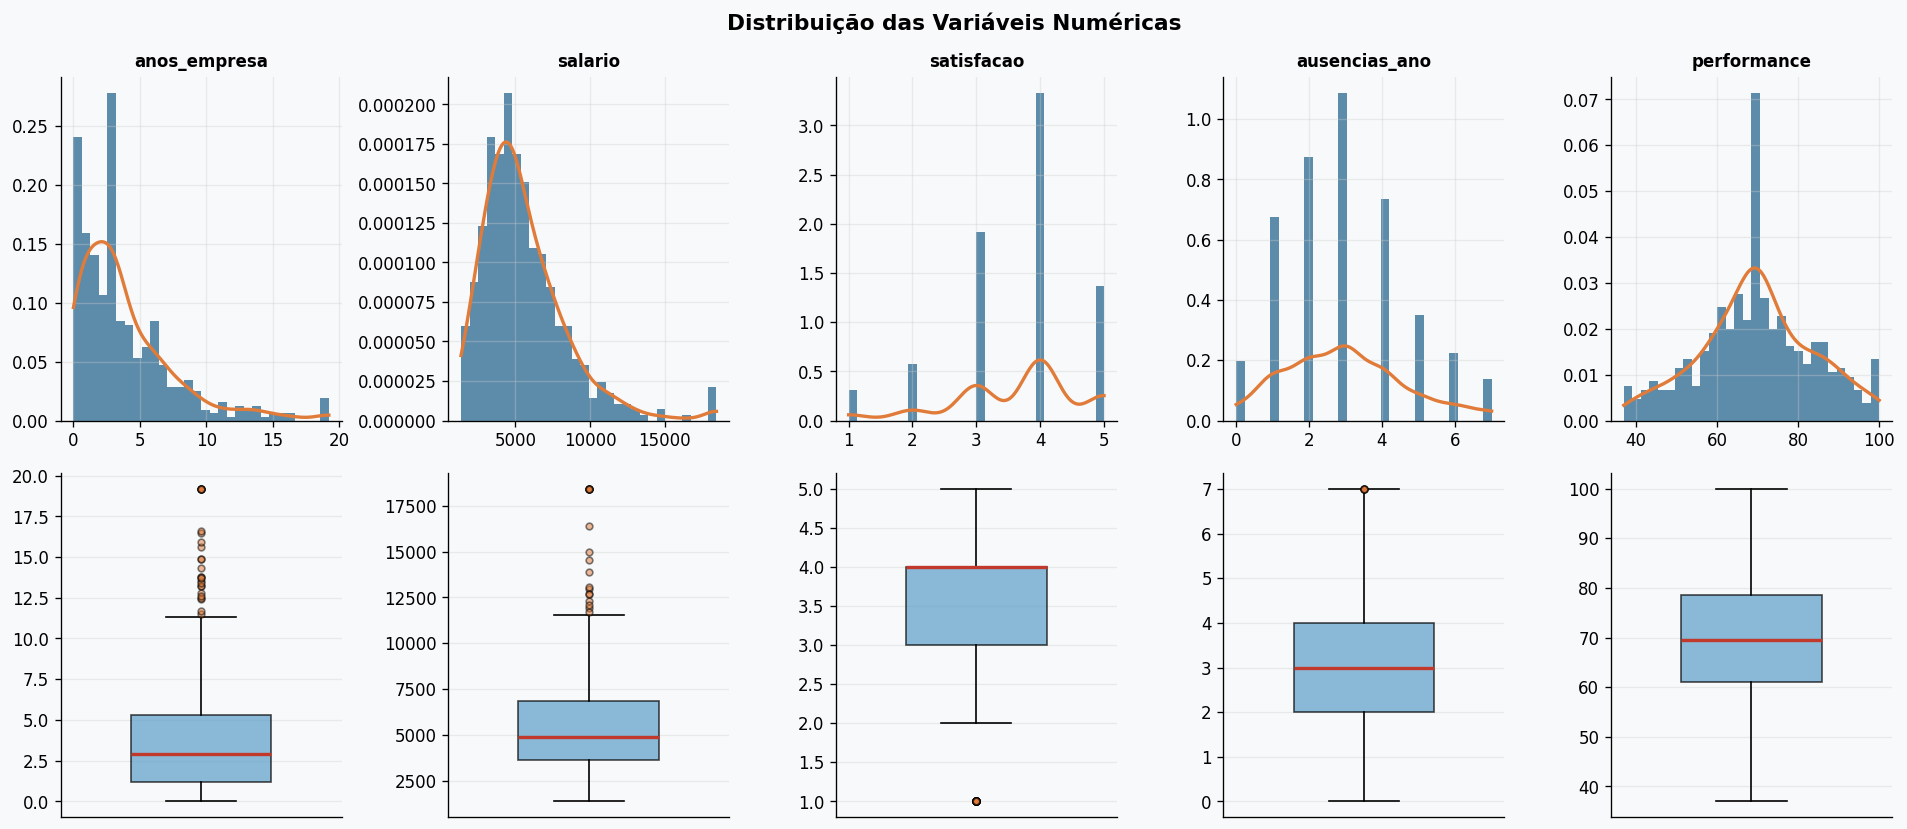

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# SEÇÃO 4 — EDA UNIVARIADA
# ══════════════════════════════════════════════════════════════════════════════
# Análise univariada = estudar cada variável individualmente.
# Aqui analisamos:
#   - Distribuição (histograma + KDE)
#   - Assimetria (skewness) e curtose
#   - Quartis e valores extremos (boxplot)

cols_num = df.select_dtypes(include=np.number).columns.tolist()

# Removemos colunas de ID (alta cardinalidade, não interessantes para análise)
cols_num = [c for c in cols_num if "id" not in c.lower()]

separador("ESTATÍSTICAS DESCRITIVAS")
# df.describe() retorna: count, mean, std, min, 25%, 50%, 75%, max
# Adicionamos skewness e kurtosis que o describe() padrão não inclui
desc = df[cols_num].describe().T
desc["skewness"] = df[cols_num].skew()
desc["kurtosis"] = df[cols_num].kurtosis()

# Formatamos para exibição
pd.set_option("display.float_format", "{:.2f}".format)
display(desc.round(2))

# ── Interpretação automática de skewness ─────────────────────────────────────
# Skewness (assimetria):
#   > 1  ou < -1 → assimetria forte (log-transform pode ajudar em modelos)
#   0.5 a 1      → assimetria moderada
#   -0.5 a 0.5   → aproximadamente simétrica
print()
separador("DIAGNÓSTICO DE ASSIMETRIA")
for col in cols_num:
    skew = df[col].skew()
    if abs(skew) > 1:
        print(f"  ⚠️  {col:<25} skewness={skew:+.2f}  → assimetria FORTE — considere log-transform")
    elif abs(skew) > 0.5:
        print(f"  ℹ️  {col:<25} skewness={skew:+.2f}  → assimetria moderada")
    else:
        print(f"  ✅ {col:<25} skewness={skew:+.2f}  → aproximadamente simétrica")

# ── Gráficos: histograma + boxplot para cada coluna numérica ─────────────────
n_cols_plot = min(len(cols_num), 6)   # Plota no máximo 6 colunas
cols_plot = cols_num[:n_cols_plot]

fig, axes = plt.subplots(2, n_cols_plot, figsize=(n_cols_plot * 3.2, 7),
                         facecolor=PALETTE["bg"])
fig.suptitle("Distribuição das Variáveis Numéricas", fontsize=13, fontweight="bold")

for i, col in enumerate(cols_plot):
    # Linha 1: histograma com KDE (Kernel Density Estimation)
    # KDE é uma versão suavizada do histograma — mostra a distribuição real
    ax_hist = axes[0, i] if n_cols_plot > 1 else axes[0]
    ax_hist.hist(df[col].dropna(), bins=30, color=PALETTE["primary"],
                 alpha=0.7, edgecolor="none", density=True)

    # Sobrepõe a curva KDE usando scipy
    # gaussian_kde estima a função de densidade de probabilidade
    kde_data = df[col].dropna()
    if kde_data.std() > 0:
        kde = stats.gaussian_kde(kde_data)
        x_range = np.linspace(kde_data.min(), kde_data.max(), 200)
        ax_hist.plot(x_range, kde(x_range), color=PALETTE["accent"], linewidth=2)

    ax_hist.set_title(col, fontsize=10, fontweight="bold")
    ax_hist.set_xlabel("")

    # Linha 2: boxplot
    # O boxplot mostra: mínimo, Q1 (25%), mediana, Q3 (75%), máximo e outliers
    ax_box = axes[1, i] if n_cols_plot > 1 else axes[1]
    bp = ax_box.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                        widths=0.5,
                        boxprops=dict(facecolor=PALETTE["secondary"], alpha=0.7),
                        medianprops=dict(color=PALETTE["danger"], linewidth=2),
                        flierprops=dict(marker="o", markerfacecolor=PALETTE["accent"],
                                        markersize=4, alpha=0.5))
    ax_box.set_xticks([])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_univariada.png", dpi=150, bbox_inches="tight")
plt.show()

## 🔗 Seção 5 — EDA Bivariada com Testes de Significância

> **Diferencial:** Correlações com **p-valor e intervalo de confiança** — não apenas o coeficiente visual.

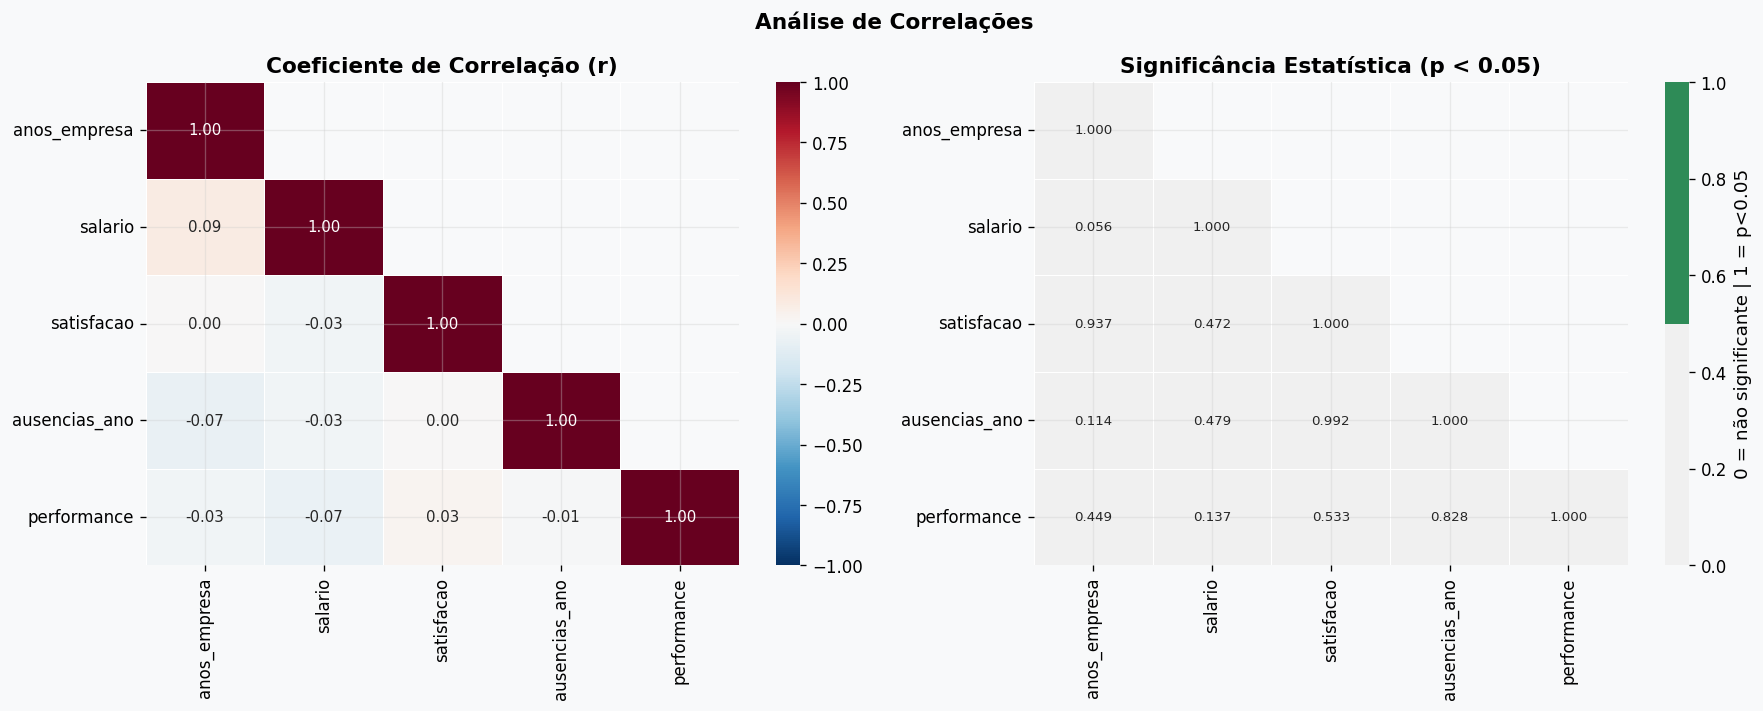

═══════════════════ TOP CORRELAÇÕES SIGNIFICANTES ═══════════════════
  Nenhuma correlação significante encontrada (p < 0.05)


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# SEÇÃO 5 — EDA BIVARIADA COM TESTES DE SIGNIFICÂNCIA
# ══════════════════════════════════════════════════════════════════════════════
# A maioria dos templates mostra uma heatmap de correlação e para.
# Aqui vamos além: testamos a significância estatística de cada correlação
# e informamos se podemos confiar nela ou se pode ser ruído aleatório.

cols_num = [c for c in df.select_dtypes(include=np.number).columns
            if "id" not in c.lower()]

# ── Matriz de correlação com p-valores ───────────────────────────────────────
# Para cada par de colunas, calculamos:
#   r  = coeficiente de Pearson (-1 a 1)
#   p  = p-valor (probabilidade de observar esta correlação por acaso)
# Convenção: p < 0.05 → correlação estatisticamente significante

n = len(cols_num)
corr_matrix  = pd.DataFrame(np.zeros((n, n)), index=cols_num, columns=cols_num)
pval_matrix  = pd.DataFrame(np.ones((n, n)),  index=cols_num, columns=cols_num)

for i, col1 in enumerate(cols_num):
    for j, col2 in enumerate(cols_num):
        if i != j:
            # Removemos NaN dos dois arrays simultaneamente
            mask = df[col1].notna() & df[col2].notna()
            x, y = df.loc[mask, col1], df.loc[mask, col2]
            if len(x) > 3:
                r, p = stats.pearsonr(x, y)
                corr_matrix.loc[col1, col2] = r
                pval_matrix.loc[col1, col2] = p
        else:
            corr_matrix.loc[col1, col2] = 1.0

# ── Heatmap de correlação ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor=PALETTE["bg"])
fig.suptitle("Análise de Correlações", fontsize=13, fontweight="bold")

# Heatmap do coeficiente r
mask_upper = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask_upper,        # Mostra só o triângulo inferior (evita redundância)
    annot=True,             # Mostra os valores dentro das células
    fmt=".2f",
    cmap="RdBu_r",          # Vermelho = positivo, Azul = negativo
    center=0,               # Centro da escala de cor em 0 (sem correlação)
    vmin=-1, vmax=1,
    ax=axes[0],
    linewidths=0.5,
    annot_kws={"size": 9}
)
axes[0].set_title("Coeficiente de Correlação (r)")

# Heatmap de significância — mostra quais correlações são confiáveis
# Células escuras = p < 0.05 (significante) | Células claras = não significante
sig_matrix = (pval_matrix < 0.05).astype(int)
sig_mask = np.triu(np.ones_like(sig_matrix, dtype=bool), k=1)
sns.heatmap(
    sig_matrix,
    mask=sig_mask,
    annot=pval_matrix.round(3),
    fmt=".3f",
    cmap=["#F0F0F0", "#2E8B57"],   # Cinza = não sig. | Verde = significante
    vmin=0, vmax=1,
    ax=axes[1],
    linewidths=0.5,
    annot_kws={"size": 8},
    cbar_kws={"label": "0 = não significante | 1 = p<0.05"}
)
axes[1].set_title("Significância Estatística (p < 0.05)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_correlacoes.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Ranking das correlações mais fortes e significantes ───────────────────────
separador("TOP CORRELAÇÕES SIGNIFICANTES")
pares = []
for i, col1 in enumerate(cols_num):
    for j, col2 in enumerate(cols_num):
        if i < j:   # Evita duplicatas
            r = corr_matrix.loc[col1, col2]
            p = pval_matrix.loc[col1, col2]
            if p < 0.05:
                # Tamanho do efeito segundo Cohen (1988):
                # |r| < 0.1 → negligível | 0.1-0.3 → pequeno
                # 0.3-0.5   → médio      | > 0.5   → grande
                if abs(r) >= 0.5:   efeito = "Grande"
                elif abs(r) >= 0.3: efeito = "Médio"
                elif abs(r) >= 0.1: efeito = "Pequeno"
                else:               efeito = "Negligível"
                pares.append((col1, col2, r, p, efeito))

pares.sort(key=lambda x: abs(x[2]), reverse=True)

if pares:
    for col1, col2, r, p, efeito in pares[:10]:
        direcao = "↑ positiva" if r > 0 else "↓ negativa"
        print(f"  {col1} × {col2}")
        print(f"    r={r:+.3f}  p={p:.4f}  efeito={efeito}  correlação {direcao}")
        print()
else:
    print("  Nenhuma correlação significante encontrada (p < 0.05)")

## 🧪 Seção 6 — Testes de Hipótese

> **Diferencial:** Testamos automaticamente normalidade e comparamos grupos com os testes estatísticos corretos para cada situação.

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# SEÇÃO 6 — TESTES DE HIPÓTESE AUTOMÁTICOS
# ══════════════════════════════════════════════════════════════════════════════

cols_num = [c for c in df.select_dtypes(include=np.number).columns
            if "id" not in c.lower()]
cols_cat = [c for c in df.select_dtypes(include="object").columns
            if df[c].nunique() <= 10 and "id" not in c.lower() and "nome" not in c.lower()]

# ── TESTE 1: Normalidade (Shapiro-Wilk) ──────────────────────────────────────
# Hipótese nula (H0): os dados seguem distribuição normal
# Se p > 0.05 → não rejeitamos H0 → dados podem ser normais
# Se p < 0.05 → rejeitamos H0 → dados NÃO são normais
# IMPORTANTE: Para n > 5.000, use Kolmogorov-Smirnov; Shapiro-Wilk é mais
# preciso para amostras pequenas (n < 5.000).
separador("TESTE DE NORMALIDADE (SHAPIRO-WILK)")
normalidade = {}
for col in cols_num:
    amostra = df[col].dropna()
    # Shapiro-Wilk fica lento para n > 5000 — amostras grandes
    if len(amostra) > 5000:
        amostra = amostra.sample(5000, random_state=42)
    stat, p = stats.shapiro(amostra)
    normal = p > 0.05
    normalidade[col] = normal
    simbolo = "✅ Normal" if normal else "❌ Não-normal"
    print(f"  {simbolo:<18} {col:<25}  W={stat:.4f}  p={p:.4f}")

# ── TESTE 2: Comparação de grupos ─────────────────────────────────────────────
# Para comparar uma variável numérica entre grupos categóricos:
# - 2 grupos, normal:     t-test de Student (paramétrico)
# - 2 grupos, não-normal: Mann-Whitney U (não-paramétrico)
# - 3+ grupos, normal:    ANOVA
# - 3+ grupos, não-normal: Kruskal-Wallis
# Esta lógica de seleção automática é o diferencial do template.

if len(cols_cat) > 0 and len(cols_num) > 0:
    print()
    separador("COMPARAÇÃO DE GRUPOS")

    col_cat = cols_cat[0]   # Usamos a primeira coluna categórica como agrupador
    grupos = df[col_cat].unique()

    for col_num in cols_num[:3]:   # Testamos as 3 primeiras numéricas
        grupo_data = [df.loc[df[col_cat] == g, col_num].dropna() for g in grupos]
        grupo_data = [g for g in grupo_data if len(g) >= 5]  # Mínimo 5 obs por grupo

        if len(grupo_data) < 2:
            continue

        eh_normal = normalidade.get(col_num, False)
        n_grupos  = len(grupo_data)

        if n_grupos == 2:
            if eh_normal:
                # t-test: compara médias de 2 grupos normais
                stat, p = stats.ttest_ind(grupo_data[0], grupo_data[1])
                teste_nome = "t-test"
            else:
                # Mann-Whitney: versão não-paramétrica do t-test
                stat, p = stats.mannwhitneyu(grupo_data[0], grupo_data[1])
                teste_nome = "Mann-Whitney"
        else:
            if eh_normal:
                # ANOVA: compara médias de 3+ grupos normais
                stat, p = stats.f_oneway(*grupo_data)
                teste_nome = "ANOVA"
            else:
                # Kruskal-Wallis: versão não-paramétrica da ANOVA
                stat, p = stats.kruskal(*grupo_data)
                teste_nome = "Kruskal-Wallis"

        sig = "✅ Diferença significante" if p < 0.05 else "❌ Sem diferença significante"
        print(f"  {col_num} por {col_cat}")
        print(f"    Teste: {teste_nome}  |  stat={stat:.3f}  |  p={p:.4f}  |  {sig}")
        print()

════════════════ TESTE DE NORMALIDADE (SHAPIRO-WILK) ════════════════
  ❌ Não-normal       anos_empresa               W=0.8277  p=0.0000
  ❌ Não-normal       salario                    W=0.8797  p=0.0000
  ❌ Não-normal       satisfacao                 W=0.8688  p=0.0000
  ❌ Não-normal       ausencias_ano              W=0.9484  p=0.0000
  ❌ Não-normal       performance                W=0.9877  p=0.0003

════════════════════════ COMPARAÇÃO DE GRUPOS ════════════════════════
  anos_empresa por departamento
    Teste: Kruskal-Wallis  |  stat=2.648  |  p=0.6184  |  ❌ Sem diferença significante

  salario por departamento
    Teste: Kruskal-Wallis  |  stat=0.312  |  p=0.9890  |  ❌ Sem diferença significante

  satisfacao por departamento
    Teste: Kruskal-Wallis  |  stat=1.512  |  p=0.8244  |  ❌ Sem diferença significante



## 🎯 Seção 7 — Detecção de Outliers (3 Métodos)

> **Diferencial:** Comparamos três métodos com consenso — um ponto só é considerado outlier se **pelo menos 2 métodos** concordam.

══════════════════ RESULTADO — DETECÇÃO DE OUTLIERS ══════════════════
  Método IQR:              66 pontos
  Método Z-score:          19 pontos
  Método Isolation Forest: 25 pontos
  CONSENSO (≥2 métodos):   31 outliers confirmados (6.2%)


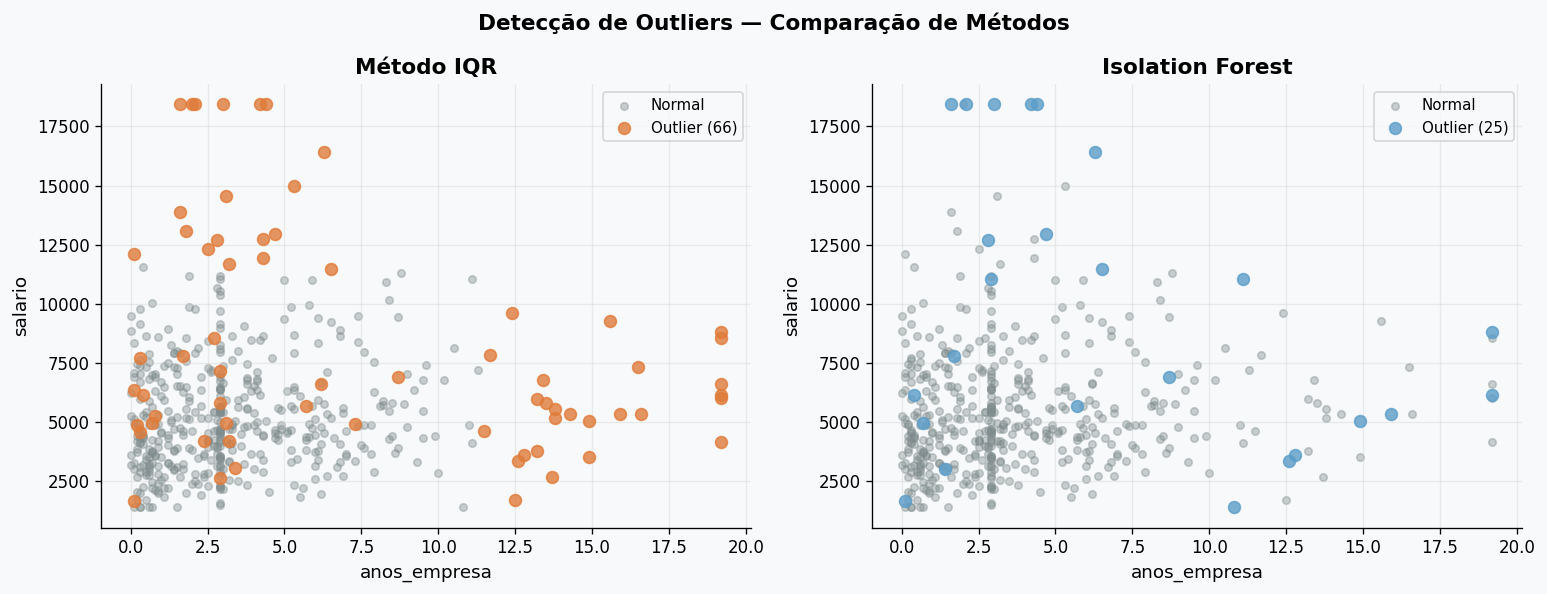

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# SEÇÃO 7 — DETECÇÃO DE OUTLIERS COM MÚLTIPLOS MÉTODOS
# ══════════════════════════════════════════════════════════════════════════════
# Cada método tem pontos fortes e fracos:
#
# MÉTODO 1 — IQR (Interquartile Range):
#   Clássico e robusto. Define outlier como valor além de 1.5 × IQR acima
#   do Q3 ou abaixo do Q1. Não assume distribuição normal.
#
# MÉTODO 2 — Z-score:
#   Assume distribuição normal. Outlier = valor além de 3 desvios padrão
#   da média. Sensível a outliers extremos que distorcem a média.
#
# MÉTODO 3 — Isolation Forest (Machine Learning):
#   Algoritmo de árvores que isola pontos anômalos. Funciona bem em alta
#   dimensionalidade e não assume distribuição. O parâmetro contamination
#   indica a fração esperada de outliers (padrão: 5%).
#
# CONSENSO: consideramos outlier confirmado o ponto identificado por
# pelo menos 2 dos 3 métodos.

cols_num = [c for c in df.select_dtypes(include=np.number).columns
            if "id" not in c.lower()]

outlier_flags = pd.DataFrame(index=df.index)

# ── MÉTODO 1: IQR ─────────────────────────────────────────────────────────────
iqr_flags = pd.Series(False, index=df.index)
for col in cols_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_flags |= (df[col] < lower) | (df[col] > upper)
outlier_flags["iqr"] = iqr_flags

# ── MÉTODO 2: Z-score ─────────────────────────────────────────────────────────
z_flags = pd.Series(False, index=df.index)
for col in cols_num:
    z = np.abs(stats.zscore(df[col].fillna(df[col].median())))
    z_flags |= (z > 3)
outlier_flags["zscore"] = z_flags

# ── MÉTODO 3: Isolation Forest ───────────────────────────────────────────────
X = df[cols_num].fillna(df[cols_num].median())
scaler = StandardScaler()   # Padroniza para média 0 e desvio 1 (IF precisa disso)
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
# fit_predict retorna: 1 = normal, -1 = outlier
preds = iso.fit_predict(X_scaled)
outlier_flags["isolation_forest"] = (preds == -1)

# ── CONSENSO ──────────────────────────────────────────────────────────────────
# Um ponto é outlier confirmado se pelo menos 2 métodos dizem que é
outlier_flags["votos"] = outlier_flags.sum(axis=1)
outlier_flags["outlier_consenso"] = outlier_flags["votos"] >= 2

n_outliers = outlier_flags["outlier_consenso"].sum()

separador("RESULTADO — DETECÇÃO DE OUTLIERS")
print(f"  Método IQR:              {outlier_flags['iqr'].sum():,} pontos")
print(f"  Método Z-score:          {outlier_flags['zscore'].sum():,} pontos")
print(f"  Método Isolation Forest: {outlier_flags['isolation_forest'].sum():,} pontos")
print(f"  CONSENSO (≥2 métodos):   {n_outliers:,} outliers confirmados ({n_outliers/len(df)*100:.1f}%)")

# ── Visualização comparativa ──────────────────────────────────────────────────
if len(cols_num) >= 2:
    col_x, col_y = cols_num[0], cols_num[1]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=PALETTE["bg"])
    fig.suptitle("Detecção de Outliers — Comparação de Métodos", fontsize=13, fontweight="bold")

    cores_metodo = {
        "iqr":             PALETTE["accent"],
        "isolation_forest": PALETTE["secondary"],
        "outlier_consenso": PALETTE["danger"],
    }

    for ax, (metodo, cor) in zip(axes[:2], list(cores_metodo.items())[:2]):
        flags = outlier_flags[metodo]
        ax.scatter(df.loc[~flags, col_x], df.loc[~flags, col_y],
                   c=PALETTE["neutral"], alpha=0.4, s=20, label="Normal")
        ax.scatter(df.loc[flags, col_x], df.loc[flags, col_y],
                   c=cor, alpha=0.8, s=50, label=f"Outlier ({flags.sum()})", zorder=5)
        titulo = {"iqr": "Método IQR", "isolation_forest": "Isolation Forest"}
        ax.set_title(titulo.get(metodo, metodo))
        ax.set_xlabel(col_x); ax.set_ylabel(col_y)
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "04_outliers.png", dpi=150, bbox_inches="tight")
    plt.show()

# Adicionamos a flag de outlier ao DataFrame para uso posterior
df["_outlier"] = outlier_flags["outlier_consenso"]

## 📄 Seção 8 — Relatório HTML Automático

> **Diferencial:** Geração automática de relatório com **narrativa interpretativa** — não apenas tabelas, mas frases que explicam os achados.

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# SEÇÃO 8 — GERAÇÃO DO RELATÓRIO HTML
# ══════════════════════════════════════════════════════════════════════════════
# Este relatório é o entregável final para clientes e stakeholders.
# Combina os resultados de todas as seções anteriores num documento
# navegável com narrativa automática.

import base64
from pathlib import Path

def img_to_base64(path):
    """Converte imagem para base64 para embutir no HTML (sem dependências externas)."""
    try:
        with open(path, "rb") as f:
            return base64.b64encode(f.read()).decode()
    except FileNotFoundError:
        return ""

def narrativa_qualidade(score):
    """Gera texto interpretativo baseado no score de qualidade."""
    if score >= 90:
        return f"O dataset apresenta <strong>qualidade excelente ({score}/100)</strong>. Os dados estão bem estruturados e prontos para modelagem."
    elif score >= 70:
        return f"O dataset apresenta <strong>boa qualidade ({score}/100)</strong> após a limpeza aplicada. Algumas inconsistências foram corrigidas automaticamente."
    else:
        return f"O dataset apresenta <strong>qualidade abaixo do ideal ({score}/100)</strong>. Recomenda-se revisão manual antes de qualquer modelagem."

def narrativa_correlacoes(pares):
    """Gera texto sobre as correlações mais relevantes."""
    if not pares:
        return "Nenhuma correlação estatisticamente significante foi encontrada entre as variáveis numéricas."
    top = pares[0]
    direcao = "positiva" if top[2] > 0 else "negativa"
    return (f"A correlação mais forte encontrada foi entre <strong>{top[0]}</strong> e "
            f"<strong>{top[1]}</strong> (r={top[2]:+.2f}, p={top[3]:.4f}), "
            f"uma relação {direcao} com efeito {top[4].lower()}.")

# ── Construção do HTML ────────────────────────────────────────────────────────
img_dq   = img_to_base64(OUTPUT_DIR / "01_dq_score.png")
img_uni  = img_to_base64(OUTPUT_DIR / "02_univariada.png")
img_corr = img_to_base64(OUTPUT_DIR / "03_correlacoes.png")
img_out  = img_to_base64(OUTPUT_DIR / "04_outliers.png")

html = f"""<!DOCTYPE html>
<html lang="pt-BR">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Relatório EDA — {datetime.now().strftime('%d/%m/%Y')}</title>
<style>
  * {{ box-sizing: border-box; margin: 0; padding: 0; }}
  body {{ font-family: 'Segoe UI', Arial, sans-serif; background: #F8F9FA; color: #2D2D2D; }}
  .header {{ background: #1B5E8A; color: white; padding: 40px; }}
  .header h1 {{ font-size: 28px; margin-bottom: 8px; }}
  .header p  {{ opacity: 0.85; font-size: 14px; }}
  .container {{ max-width: 1100px; margin: 0 auto; padding: 32px 24px; }}
  .section {{ background: white; border-radius: 12px; padding: 28px; margin-bottom: 24px; box-shadow: 0 1px 4px rgba(0,0,0,0.08); }}
  .section h2 {{ font-size: 18px; color: #1B5E8A; margin-bottom: 16px; padding-bottom: 10px; border-bottom: 2px solid #E8F0F8; }}
  .narrative {{ background: #EEF5FB; border-left: 4px solid #1B5E8A; padding: 14px 18px; border-radius: 0 8px 8px 0; margin-bottom: 18px; font-size: 14px; line-height: 1.7; }}
  .kpi-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(160px, 1fr)); gap: 16px; margin-bottom: 20px; }}
  .kpi {{ background: #F0F6FB; border-radius: 10px; padding: 18px; text-align: center; }}
  .kpi-val {{ font-size: 26px; font-weight: 700; color: #1B5E8A; }}
  .kpi-label {{ font-size: 12px; color: #666; margin-top: 4px; }}
  .chart-img {{ width: 100%; border-radius: 8px; margin-top: 16px; }}
  .log-item {{ display: flex; gap: 10px; padding: 8px 0; border-bottom: 1px solid #F0F0F0; font-size: 13px; }}
  .log-item:last-child {{ border-bottom: none; }}
  .footer {{ text-align: center; padding: 24px; color: #999; font-size: 12px; }}
  table {{ width: 100%; border-collapse: collapse; font-size: 13px; }}
  th {{ text-align: left; padding: 10px; background: #F0F6FB; color: #1B5E8A; font-weight: 600; }}
  td {{ padding: 8px 10px; border-bottom: 1px solid #F5F5F5; }}
  tr:hover td {{ background: #FAFAFA; }}
</style>
</head>
<body>

<div class="header">
  <h1>📊 Relatório de Análise Exploratória de Dados</h1>
  <p>Gerado em {datetime.now().strftime('%d/%m/%Y às %H:%M')} · Template EDA Profissional · Autor: Miguel Salles Reis</p>
</div>

<div class="container">

  <!-- KPIs gerais -->
  <div class="section">
    <h2>Visão Geral do Dataset</h2>
    <div class="kpi-grid">
      <div class="kpi"><div class="kpi-val">{df.shape[0]:,}</div><div class="kpi-label">Linhas</div></div>
      <div class="kpi"><div class="kpi-val">{df.shape[1]}</div><div class="kpi-label">Colunas</div></div>
      <div class="kpi"><div class="kpi-val">{dq_depois['score_total']:.0f}</div><div class="kpi-label">DQ Score</div></div>
      <div class="kpi"><div class="kpi-val">{n_outliers}</div><div class="kpi-label">Outliers</div></div>
      <div class="kpi"><div class="kpi-val">{len(log_limpeza)}</div><div class="kpi-label">Correções</div></div>
    </div>
  </div>

  <!-- Qualidade dos dados -->
  <div class="section">
    <h2>Data Quality Score</h2>
    <div class="narrative">{narrativa_qualidade(dq_depois['score_total'])}</div>
    {'<img class="chart-img" src="data:image/png;base64,' + img_dq + '">' if img_dq else ''}
  </div>

  <!-- Log de limpeza -->
  <div class="section">
    <h2>Log de Limpeza Automática</h2>
    <div>
      {''.join(f'<div class="log-item"><span>{e}</span><span><strong>{cat}</strong> — {msg}</span></div>' for e, cat, msg in log_limpeza)}
    </div>
  </div>

  <!-- Univariada -->
  <div class="section">
    <h2>Distribuição das Variáveis</h2>
    {'<img class="chart-img" src="data:image/png;base64,' + img_uni + '">' if img_uni else ''}
  </div>

  <!-- Correlações -->
  <div class="section">
    <h2>Análise de Correlações</h2>
    <div class="narrative">{narrativa_correlacoes(pares if 'pares' in dir() else [])}</div>
    {'<img class="chart-img" src="data:image/png;base64,' + img_corr + '">' if img_corr else ''}
  </div>

  <!-- Outliers -->
  <div class="section">
    <h2>Detecção de Outliers</h2>
    <div class="narrative">
      Foram identificados <strong>{n_outliers} outliers confirmados ({n_outliers/len(df)*100:.1f}%)</strong> pelo consenso de múltiplos métodos (IQR + Z-score + Isolation Forest).
      {'Recomenda-se investigação manual antes de remover estes pontos.' if n_outliers > 0 else 'O dataset não apresenta outliers preocupantes.'}
    </div>
    {'<img class="chart-img" src="data:image/png;base64,' + img_out + '">' if img_out else ''}
  </div>

</div>

<div class="footer">
  Relatório gerado automaticamente · Template EDA Profissional · Miguel Salles Reis ·
  <a href="https://github.com/miguelsalles-dtscience">github.com/miguelsalles-dtscience</a>
</div>

</body>
</html>"""

# Salvamos o relatório
report_path = OUTPUT_DIR / "relatorio_eda.html"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(html)

print(f"✅ Relatório gerado: {report_path.resolve()}")
print(f"   Abra o arquivo no seu navegador para visualizar.")

# No Jupyter, podemos exibir um link clicável
from IPython.display import display, HTML as IHTML
display(IHTML(f'<a href="{report_path}" target="_blank">🔗 Abrir Relatório HTML</a>'))

✅ Relatório gerado: C:\Users\migue\OneDrive\Desktop\portfolio-template-eda\outputs\relatorio_eda.html
   Abra o arquivo no seu navegador para visualizar.


---
## ✅ Próximos Passos

Após executar este template, você terá na pasta `outputs/`:

| Arquivo | Conteúdo |
|---------|----------|
| `01_dq_score.png` | Gráfico do Data Quality Score |
| `02_univariada.png` | Distribuições e boxplots |
| `03_correlacoes.png` | Heatmap de correlações + significância |
| `04_outliers.png` | Comparação dos métodos de detecção |
| `relatorio_eda.html` | Relatório completo para o cliente |

**Para usar com seus dados:**
1. Altere `CSV_PATH` na Seção 1
2. Execute todas as células (`Kernel → Restart & Run All`)
3. Compartilhe o `relatorio_eda.html` com o cliente

---
*Template EDA Profissional · Miguel Salles Reis · [github.com/miguelsalles-dtscience](https://github.com/miguelsalles-dtscience)*
